# Practical 6: Constrained Optimization: Equality Constraints

In [5]:
# Paquets
import numpy as np
from numpy.linalg import norm, solve

## Brief introduction to Sequential quadratic programming

Sequential quadratic programming is a popular technique for solving non-linear constrained problems.   The main idea is to obtain, at each iteration, a search direction by solving an approximation of the original problem.  In particular, for each iteration we will solve a quadratic program, that is, a problem with a quadratic objective function and linear constraints.

Our focus is to solve (we focus only on one constraint)

$$
\begin{aligned}
\min_{x}\;& f(x) \\
\text{s.t.}\;& h(x)=0
\end{aligned}
$$

The Lagrangian is

$$
\mathcal{L}(x,\lambda) = f(x) - \lambda\, h(x)
$$

The first order optimality condition is

$$
\nabla \mathcal{L}(x,\lambda) = 0
$$

Assume that we use the Newton method to minimize the Lagrange function

$$
\begin{pmatrix}
x^{k+1} \\
\lambda^{k+1}
\end{pmatrix}
=
\begin{pmatrix}
x^{k} \\
\lambda^{k}
\end{pmatrix}
+ \alpha^{k}
\begin{pmatrix}
d^{k} \\
\nu^{k}
\end{pmatrix}
\tag{1}
$$

where $\mathbf{d}^k$ and $\nu^k$ are obtained as the solution to the Newton linear system

$$
\nabla^2 \mathcal{L}(x^k,\lambda^k)
\begin{pmatrix}
d^k \\
\nu^k
\end{pmatrix}
=
-\nabla \mathcal{L}(x^k,\lambda^k)
$$

This linear system has the form

$$
\begin{pmatrix}
\nabla^2_{xx} \mathcal{L}(x^k,\lambda^k) & -\nabla h(x^k) \\
-\nabla h(x^k)^T & 0
\end{pmatrix}
\begin{pmatrix}
d^k \\
\nu^k
\end{pmatrix}
=
\begin{pmatrix}
-\nabla_x \mathcal{L}(x^k,\lambda^k) \\
h(x^k)
\end{pmatrix}
\tag{2}
$$

The latter system of equations represents the first-order optimality conditions of the following optimization problem:

$$
\begin{aligned}
\min_{\mathbf{d}} \quad &
q(d) = \tfrac{1}{2}\, d^T\!\left[\nabla^2_{xx} \mathcal{L}(x^k,\lambda^k)\right] d
+ d^T \left[\nabla_x \mathcal{L}(x^k,\lambda^k)\right]
\\[2mm]
\text{s.t.} \quad &
\left[\nabla h(x^k)\right]^T d + h(x^k) = 0
\end{aligned}
\tag{3}
$$

This optimization problem is a quadratic program; that is, it is the minimization of a quadratic function subject to linear constraints. The quadratic function is a Taylor series approximation to the Lagrangian at $(x^k,\lambda^k)$ and the constraints are a linear approximation to $h(x^k + d)=0$.

In a Sequential Quadratic Optimization method, at each iteration the linear system of equation (2) is solved to obtain $(d^k,\nu^k)$. These are used to update $(x^k,\lambda^k)$, and the process repeats at the new point.



## Experiments

In the following sections, we will try to solve to the problem

$$
\begin{aligned}
\min_{x_1, x_2}\quad & f(x_1,x_2) = e^{3x_1} + e^{-4x_2} \\
\text{s.t.}\quad & h(x_1,x_2) = x_1^2 + x_2^2 - 1 = 0
\end{aligned}
$$

via applying the Sequential Quadratic Optimization method.

The solution to this problem is $(x_1^*, x_2^*) \approx (-0.74834, 0.66332)^T$  with  $\lambda^* \approx -0.21233$  which in fact is a **saddle point**! The Hessian matrix of the Lagrangian has two positive and one negative eigenvalues.


---

**GRAFICS DE LA FUNCIÓ !!!**

---

Taking this information into account, we will implamented different approaches:

### Experiment 1

**One simple way to proceed is to take $\alpha^k = 1$ and iteratively update the current point to obtain the next. This is a simple way to proceed that is proposed to perform first. The stopping condition should be performed over $\nabla_x \mathcal{L}$. Test this approach and check if it works using the starting point proposed in the example**

---

Firstly, we will define the necessary function to realise the updates in each iterations

In [17]:

# Functions 

# funció objectiu
def f(x1,x2):
    return np.exp(3*x1) + np.exp(-4*x2)
    
def grad_f(x1,x2):

    grad_x1 = 3*np.exp(3*x1)
    grad_x2 = -4*np.exp(-4*x2)

    return np.array([[grad_x1],[grad_x2]])

def hessian_f(x1,x2):
    h11 = 9 * np.exp(3*x1)
    h22 = 16 * np.exp(-4*x2)

    return np.array([[h11, 0],[0, h22]])

def h(x1,x2):
    return x1**2 + x2**2 - 1

def hessian_h(x1,x2):

    H = np.array([[2,0],
                  [0,2]])
    
    return H


def grad_h(x1,x2):

    grad_x1 = 2*x1
    grad_x2 = 2*x2
    return np.array([[grad_x1],[grad_x2]])


def L(x1,x2,lamb):

    return f(x1,x2) - lamb * h(x1,x2)

def grad_Lx(x1,x2,lamb):

    return grad_f(x1,x2) - lamb * grad_h(x1,x2)

def grad_L(x1,x2,lamb):

    grad_x = grad_Lx(x1,x2,lamb)
    grad_lamb = -h(x1,x2)

    G = np.array([[grad_x[0,0]],
                     [grad_x[1,0]],
                     [grad_lamb]])
    
    return G

def hessian_Lx(x1,x2,lamb):

    Lx = hessian_f(x1,x2) - lamb * hessian_h(x1,x2)
    return Lx

def hessian_L(x1,x2, lamb):

    block_sup = np.hstack((hessian_Lx(x1,x2,lamb), - grad_h(x1,x2)))
    block_inf = np.hstack((-grad_h(x1,x2).T, np.array([[0]])))

    H = np.vstack((block_sup, block_inf))
    return H


def newton_sys(x1,x2,lamb):

    lhs = hessian_L(x1, x2, lamb)
    rhs = -1 * grad_L(x1,x2,lamb)

    delta = solve(lhs, rhs)

    return delta

def update(x1,x2,lamb, alp):
    
    sol = newton_sys(x1,x2,lamb)

    x1_up = x1 + alp * sol[0,0]
    x2_up = x2 + alp * sol[1,0]
    lamb_up = lamb + alp * sol[2,0]

    return x1_up, x2_up, lamb_up

Secondly, we will apply the update function incorporate all the necessary function to obtain our points update. As the problem statement says, we choose $(x1^0, x2^0)=(-1,1)$ and $\lambda^0=-1$ starting points. Also, we introduce a stopping condition to $\nabla_x \mathcal{L}$ like, the iterations will stop when de norm of $\nabla_x \mathcal{L}$  is lower than a tolerance.

In [157]:
# starting point
x1_k = -1
x2_k = 1
lamb_k = -1

# tolerància
tol = 1e-15

# alpha
alp_k = 1

# contador iteracions
cont = 0

# bucle

while norm(grad_Lx(x1_k, x2_k, lamb_k))>tol : 
    print("Iteració", cont)
    x1_k, x2_k, lamb_k = update(x1_k, x2_k, lamb_k, alp_k)
    cont += 1

print("SOLUCIÓ FINAL \n --------------- \n (x1*, x2*) = (", x1_k, ",", x2_k, ") \n lamb* =", lamb_k)


Iteració 0
Iteració 1
Iteració 2
Iteració 3
Iteració 4
SOLUCIÓ FINAL 
 --------------- 
 (x1*, x2*) = ( -0.7483354868836649 , 0.6633204346849177 ) 
 lamb* = -0.2123249355499713


We can check if the point solution verify the equality constraint:

In [158]:
hk = h(x1_k, x2_k)

print("The point verify the equality constrain with h(x1*, x2*) = ", hk)

The point verify the equality constrain with h(x1*, x2*) =  0.0


Now, we must check this point is really a saddle point as the problem statement mention. For check it, we must compute the eigenvalues for the hessian of the Lagrangian function and check that all of them are differet to zero and not with same sign.

In [159]:
vaps = np.linalg.eigvals(hessian_L(x1_k, x2_k, lamb_k))
print("Eingvalues for hessian of Lagrangian:", vaps[0], ",", vaps[1], ",", vaps[2])

Eingvalues for hessian of Lagrangian: -1.4017912552840157 , 1.4723376508576118 , 2.8588107991079066


In [162]:
vaps = np.linalg.eigvals(hessian_Lx(x1_k, x2_k, lamb_k))
print("Eingvalues for hessian of Lagrangian:", vaps[0], ",", vaps[1])

Eingvalues for hessian of Lagrangian: 1.3779915752339256 , 1.5513656194475758


As the statement mention, this correspond to a saddle point. We can check this visually:

In [146]:
import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import interact, FloatSlider


# Optimal point
x1_star = -0.7483354868836933
x2_star =  0.6633204346848969

# Grid
x1 = np.linspace(-2, 2, 400)
x2 = np.linspace(-2, 2, 400)
X1, X2 = np.meshgrid(x1, x2)

def plot_L_near_zero(lamb):
    Z = L(X1, X2, lamb)

    fig, ax = plt.subplots(figsize=(7,6))

    # Nivells centrats en 0, amb valors negatius i positius petits
    levels = np.arange(-1,1,0.05)

    CS = ax.contour(X1, X2, Z, levels=levels, cmap='coolwarm')
    ax.clabel(CS, inline=True, fontsize=8)

    # Nivell 0 ressaltat
    ax.contour(X1, X2, Z, levels=[0], colors='black', linewidths=2)

    # Punt òptim
    ax.plot(x1_star, x2_star, 'ro', markersize=8, label="Optimal point")
    ax.legend(loc="upper right")

    # Valor de L en el punt òptim per al lambda actual
    L_star = L(x1_star, x2_star, lamb)
    ax.text(
        0.02, 0.02,
        f"L(x*, λ) = {L_star:.4f}",
        transform=ax.transAxes,
        fontsize=11,
        bbox=dict(boxstyle="round", facecolor="white", alpha=0.8)
    )

    ax.set_xlabel("x1")
    ax.set_ylabel("x2")
    ax.set_title(f"L(x1, x2, λ={lamb:.2f}) - near zero levels")
    ax.grid(alpha=0.3)

    plt.show()

interact(
    plot_L_near_zero,
    lamb=FloatSlider(min=-20, max=20, step=0.1, value=0)
);

interactive(children=(FloatSlider(value=0.0, description='lamb', max=20.0, min=-20.0), Output()), _dom_classes…

Perhaps the graphics results, it's not really intuitive to understand why the optimal point it's a saddle point. Numerically, thanks to the eigenvalues obtained through the hessian, we verifty that this is not. So, another approach by fixing the objective function in the equality constrain visually, we observe;

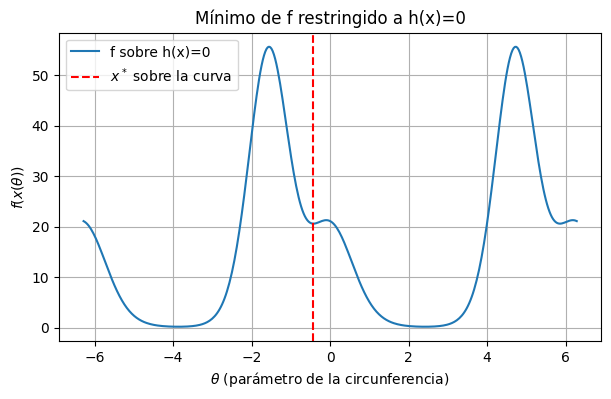

In [168]:
# Punto óptimo (aprox)
x1_star = -0.7483354868836933
x2_star =  0.6633204346848969
lambda_star = -0.21233

# possible 2
x1_star = 0.01434523154181854
x2_star = -0.9998971018719935
lambda_star = 109.16259756189383

# possible 3
x1_star = 0.99498305
x2_star = -0.10004685
lambda_star = 29.82788404

#possible 4 
x1_star = 0.9104132337752556 
x2_star = -0.41370006498293144 
lamb_star = 25.293855204184073



# 1) f sobre la restricción: x1^2 + x2^2 = 1
theta = np.linspace(-2*np.pi, 2*np.pi, 400)
x1_circle = np.cos(theta)
x2_circle = np.sin(theta)
f_circle = f(x1_circle, x2_circle)

plt.figure(figsize=(7,4))
plt.plot(theta, f_circle, label="f sobre h(x)=0")
# localizamos el theta que corresponde a x*
theta_star = np.arctan2(x2_star, x1_star)
plt.axvline(theta_star, color='r', linestyle='--', label=r"$x^*$ sobre la curva")
plt.xlabel(r"$\theta$ (parámetro de la circunferencia)")
plt.ylabel(r"$f(x(\theta))$")
plt.title("Mínimo de f restringido a h(x)=0")
plt.legend()
plt.grid(True)
plt.show()

The graph above depicts the value of the objective function $f(x_1, x_2) = e^{3x_1} + e^{-4x_2}$ constrained to the feasible curve $ h(x_1, x_2) = x_1^2 + x_2^2 - 1 = 0 $, which corresponds to the unit circle. By parameterizing this constraint using an angle $\theta$, we obtain a one-dimensional function $f(x(\theta))$. The graph of this function clearly shows a point where a local minimum is attained, coinciding with $x^* = (x_1^*, x_2^*)$. This visually confirms that, when moving solely along the constraint, any displacement around $x^*$ increases the value of the function, demonstrating that $x^*$ is a constrained minimum of the original problem.

In [138]:
f(x1_star,x2_star)

55.61965762596603

h(x* )   = 2.220446049250313e-16
h(x_off) = -0.16317585091185294


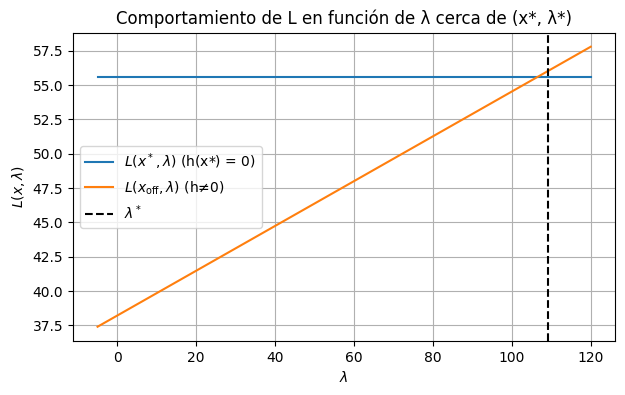

In [128]:
# Elegimos un punto ligeramente fuera de la restricción (h != 0)
x1_off = x1_star + 0.15
x2_off = x2_star + 0.10
print("h(x* )   =", h(x1_star, x2_star))   # debería ser ~0
print("h(x_off) =", h(x1_off, x2_off))     # distinto de 0

lambdas = np.linspace(-5, 120, 500)
L_star_vals = L(x1_star, x2_star, lambdas)
L_off_vals  = L(x1_off,  x2_off,  lambdas)

plt.figure(figsize=(7,4))
plt.plot(lambdas, L_star_vals, label=r"$L(x^*,\lambda)$ (h(x*) = 0)")
plt.plot(lambdas, L_off_vals,  label=r"$L(x_{\mathrm{off}},\lambda)$ (h≠0)")
plt.axvline(lambda_star, color='k', linestyle='--', label=r"$\lambda^*$")
plt.xlabel(r"$\lambda$")
plt.ylabel(r"$L(x,\lambda)$")
plt.title("Comportamiento de L en función de λ cerca de (x*, λ*)")
plt.legend()
plt.grid(True)
plt.show()


And the last graph shows how the Lagrangian $L(x_1,x_2,\lambda) = f(x_1,x_2) - \lambda\, h(x_1,x_2)$ varies when we modify the multiplier $\lambda$. When evaluating the function at the optimal feasible point $ x^* $, $h(x^*) = 0$ holds, so $L(x^*, \lambda) = f(x^*)$ and the graph is a horizontal line. This indicates that the Lagrangian does not change when varying $\lambda$ at the optimal point, showing a flat direction. In contrast, if we evaluate the Lagrangian at a nearby but non-feasible point $ x_{\mathrm{off}} $, where $ h(x_{\mathrm{off}}) \neq 0 $, we obtain a line with a non-zero slope, which can descend without limit when modifying $\lambda$. This coexistence of a flat direction and another in which the function decreases arbitrarily reveals the typical behavior of a saddle point in the augmented space $(x,\lambda)$. Therefore, although $x^*$ is a minimum under the constraint, the pair $(x^*, \lambda^*)$ is a saddle point of the Lagrangian.

### Experiment 2 

**This basic iteration also has drawbacks, leading to a number of vital questions. It is a Newton-like iteration, and thus may diverge from poor starting points. In our example we have started from a point that is near to the optimal solution. Try to perform some experiments with starting points that are farther away from the optimal solution.**

---

So, for the propouse of this statement, we will choose farther away starting points for check that the convergence to the optimal solution has fiew limitations

In [ ]:
# CHECK 1 (X1=-10, X2=5, LAMB= -1)

# starting point
x1_k = -10
x2_k = 5
lamb_k = 1

# tolerància
tol = 1e-10

# alpha
alp_k = 1

# contador iteracions
cont = 0

# bucle

while norm(grad_Lx(x1_k, x2_k, lamb_k))>tol : 
    print("Iteració", cont)
    x1_k, x2_k, lamb_k = update(x1_k, x2_k, lamb_k, alp_k)
    cont += 1

print("SOLUCIÓ FINAL \n --------------- \n (x1*, x2*) = (", x1_k, ",", x2_k, ") \n lamb* =", lamb_k)

Iteració 0
Iteració 1
Iteració 2
Iteració 3
Iteració 4
Iteració 5
Iteració 6
Iteració 7
Iteració 8
Iteració 9
Iteració 10
Iteració 11
Iteració 12
Iteració 13
Iteració 14
Iteració 15
Iteració 16
SOLUCIÓ FINAL 
 --------------- 
 (x1*, x2*) = ( -0.7483354868828299 , 0.6633204346887895 ) 
 lamb* = -0.21232493554545231


In [ ]:
# CHECK 2 (X1=1000, X2=300, LAMB= -4)

# starting point
x1_k = -0.06
x2_k = -0.22
lamb_k = -15  # 10, 20, 1 diferent lambda per trobar aquest punts

# tolerància
tol = 1e-10

# alpha
alp_k = 1

# contador iteracions
cont = 0

# bucle

while norm(grad_Lx(x1_k, x2_k, lamb_k))>tol : 
    print("Iteració", cont)
    x1_k, x2_k, lamb_k = update(x1_k, x2_k, lamb_k, alp_k)
    cont += 1

print("SOLUCIÓ FINAL \n --------------- \n (x1*, x2*) = (", x1_k, ",", x2_k, ") \n lamb* =", lamb_k)

Iteració 0
Iteració 1
Iteració 2
Iteració 3
Iteració 4
Iteració 5
Iteració 6
Iteració 7
Iteració 8
Iteració 9
Iteració 10
Iteració 11
Iteració 12
Iteració 13
Iteració 14
Iteració 15
Iteració 16
SOLUCIÓ FINAL 
 --------------- 
 (x1*, x2*) = ( 0.9104132337752556 , -0.41370006498293144 ) 
 lamb* = 25.293855204184073


In [123]:
# CHECK 3 (X1=-200, X2=5, LAMB= 10)

# starting point
x1_k = -0.06
x2_k = -0.22
lamb_k = 10

# tolerància
tol = 1e-10

# alpha
alp_k = 1

# contador iteracions
cont = 0

# bucle

while norm(grad_Lx(x1_k, x2_k, lamb_k))>tol : 
    print("Iteració", cont)
    x1_k, x2_k, lamb_k = update(x1_k, x2_k, lamb_k, alp_k)
    cont += 1

print("SOLUCIÓ FINAL \n --------------- \n Iteracions necessaries", cont ," \n (x1*, x2*) = (", x1_k, ",", x2_k, ") \n lamb* =", lamb_k)

Iteració 0
Iteració 1
Iteració 2
Iteració 3
Iteració 4
Iteració 5
Iteració 6
Iteració 7
Iteració 8
Iteració 9
Iteració 10
Iteració 11
Iteració 12
SOLUCIÓ FINAL 
 --------------- 
 Iteracions necessaries 13  
 (x1*, x2*) = ( 0.01434523154181854 , -0.9998971018719935 ) 
 lamb* = 109.16259756189383


In [124]:
h(0.01434523154181854 , -0.9998971018719935)

2.220446049250313e-16

In [100]:
vaps = np.linalg.eigvals(hessian_L(x1_k, x2_k, lamb_k))
print("Eingvalues for hessian of Lagrangian:", vaps[0], ",", vaps[1], ",", vaps[2])

Eingvalues for hessian of Lagrangian: -208.92942263729665 , -0.0061026821013023674 , 654.8918309778641


### Experiment 3 

One way to find the optimal solution from points that are far away of the optimal solution is to start the optimization with another function that allows us to find an approximation to the solution we are looking for. Once an approximate solution is found, we can apply the Newton-based technique we have presented previously to find the optimal solution.

The function that allows us to find an approximation to the solution we are looking for is called, in this context, the **merit function**. Usually, a merit function is the sum of terms that include the objective function and the amount of infeasibility of the constraints. One example of a merit function for the problem we are treating is the quadratic penalty function (i.e. constraints are penalized quadratically)

$$
\mathcal{M}(x_1, x_2) = f(x_1, x_2) + \rho h(x_1, x_2)^2
$$

where $\rho$ is some positive number. The greater the value of $\rho$, the greater the penalty for infeasibility. The difficulty arises in defining a proper merit function for a particular equality constrained problem.

Here we propose you to take $\rho = 10$ (thus, we penalize a lot the constraint) and perform a classical gradient descent (with backtraking if you want) to find an approximation to the solution we are looking for. Observe if you arrive near to the optimal solution of the problem. Take into account that you may have numerical problems with the gradient. A simple way to deal with it is to normalize the gradient at each iteration, $\nabla \mathcal{M}(x) / \|\nabla \mathcal{M}(x)\|$ and use this normalized gradient as search direction.

---


So, for this propouse, we will implement this new approach trying to obtain better results than in the experiments before for far away starting point from the optimal. To do this, first we will take into account an approximation of Lagrangian by the Merit Function with quadratic penalty. Now, we'll perform a classical gradient descens to find an approximation of the optimal solution of the problem, such as,

$$
x_{k+1} = x_k - \alpha_k  \dfrac{\nabla \mathcal{M}(x_k)}{\| \nabla\mathcal{M}(x_k) \|}
$$

and a stoping criterium by $\|\nabla \mathcal{M}(x_k)\| < \text{tol}$. Then, we'll implement it but before do it, we must observa that

$$
\nabla \mathcal{M}(x_k) = \nabla \mathcal{f}(x_k) + 2 \rho \nabla \mathcal{h}(x_k)
$$

where $x_k = (x_{1}^k, x_{2}^k)$

In [ ]:
# Funcions necessaries

def M(x1,x2,rho):
    return f(x1,x2) + rho * h(x1,x2)**2

def grad_M(x1,x2,rho):

    return grad_f(x1,x2) + 2 * rho * grad_h(x1,x2)

def gradient_descens(x1,x2,rho,alp):

    grad = grad_M(x1,x2,rho)
    norma = norm(grad)

    x1_k = x1 - alp * grad[0,0] / norma
    x2_k = x2 - alp * grad[1,0] / norma


    return x1_k, x2_k


In [112]:
norm(grad_M(10,10,10))

32059423744973.39

In [122]:
# Implementació de Gradient Descens per Merti function amb stopping criterium norma gradient i maxiters

# starting point
x1_k = 10
x2_k = 10
lamb_k = 10

# tolerància
tol = 1e-5

# alpha
alp_k = 1

# rho 
rho = 10

# maxiters
maxiter = 1e2

# contador iteracions
cont = 0

# bucle

while norm(grad_M(x1_k, x2_k, rho))>tol : 
    print("Iteració", cont)
    x1_k, x2_k = gradient_descens(x1_k, x2_k, rho, alp_k)
    cont += 1
    
    print("Norma:", norm(grad_M(x1_k, x2_k, lamb_k)))
    print(x1_k, "-", x2_k)

    if cont > maxiter:
        break

print("SOLUCIÓ FINAL \n --------------- \n Iteracions necessaries", cont-1 ," \n(x1*, x2*) = (", x1_k, ",", x2_k, ") \n lamb* =", lamb_k)



Iteració 0
Norma: 1596144722165.396
9.0 - 9.999999999987523
Iteració 1
Norma: 79467366709.53041
8.0 - 9.99999999973692
Iteració 2
Norma: 3956447483.449664
7.0 - 9.999999994703407
Iteració 3
Norma: 196980147.41240045
6.000000000000005 - 9.999999893602608
Iteració 4
Norma: 9807252.125634355
5.000000000002067 - 9.999997862941138
Iteració 5
Norma: 488424.53926897555
4.000000000833821 - 9.999957076805593
Iteració 6
Norma: 24432.550288383296
3.00000033617847 - 9.999138120649805
Iteració 7
Norma: 1351.1332467627622
2.000134336739926 - 9.982767929241003
Iteració 8
Norma: 402.99654914413253
1.0448032373687006 - 9.687230299531745
Iteració 9
Norma: 354.32437051840077
0.7700680329890238 - 8.725710373854456
Iteració 10
Norma: 312.454275516316
0.5978186210621944 - 7.7406570046957786
Iteració 11
Norma: 271.7164863320064
0.4635804008334722 - 6.749707914061035
Iteració 12
Norma: 231.352867685161
0.35097517262154826 - 5.756068108809987
Iteració 13
Norma: 191.15125329939875
0.25312863397252794 - 4.760866

In [120]:
norm(grad_M(x1_k, x2_k, lamb_k))

19.068999252656493

### Experiment 4 

As previously commented, the minimizers of the merit function $\mathcal{M}(x_1, x_2)$ do not necessarily have to coincide with the minimizers of the constrained problem. Thus, once we “sufficiently” approach the optimal solution we may use the Newton method (with $\alpha = 1$) to find the solution to the problem.

Therefore the algorithm consists in starting with the Merit function to obtain an approximation to the optimal point we are looking for. Once an approximation to the solution is found, use the Newton-based method to find the optimal solution. Check if you are able to find the optimal solution to the problem.

---

## Conclusion

Hi han un total de 4 corbes de sella en els 4 punts d'inflexió quan la constraint es verifica.